# Anamoly Detection

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import img_to_array

In [ ]:
# Load the Food101 dataset
dataset, info = tfds.load('food101', with_info=True, as_supervised=True)

In [ ]:
# Explore the dataset
print(info)

tfds.core.DatasetInfo(
    name='food101',
    full_name='food101/2.0.0',
    description="""
    This dataset consists of 101 food categories, with 101'000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.
    """,
    homepage='https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/',
    data_dir='/root/tensorflow_datasets/food101/2.0.0',
    file_format=tfrecord,
    download_size=4.65 GiB,
    dataset_size=4.77 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo nu

In [ ]:
# Prepare the dataset
def preprocess(image, label):
    image = tf.image.resize(image, (128, 128))
    image = image / 255.0  # Normalize to [0,1]
    return image, label

In [ ]:
train_dataset = dataset['train']

In [ ]:
# Apply preprocessing
train_dataset = train_dataset.map(preprocess)

In [ ]:
# Convert to numpy arrays
train_images = []
train_labels = []
for image, label in tfds.as_numpy(train_dataset.take(20000)):  # Adjust the number of images if needed
    train_images.append(image)
    train_labels.append(label)
train_images = np.array(train_images)
train_labels = np.array(train_labels)

In [ ]:
# Split the dataset into train and test
X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

In [ ]:
print(f'Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}')

Training set shape: (16000, 128, 128, 3), Validation set shape: (4000, 128, 128, 3)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [ ]:
# Define the autoencoder architecture
input_img = Input(shape=(128, 128, 3))

In [ ]:
# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

In [ ]:
# Decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

In [ ]:
# Autoencoder model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
# Train the autoencoder
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=64, validation_data=(X_val, X_val))

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 0.0264 - val_loss: 0.0063
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0058 - val_loss: 0.0049
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0041 - val_loss: 0.0038
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0037 - val_loss: 0.0036
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0035 - val_loss: 0.0034
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Calculate reconstruction error
reconstructed = autoencoder.predict(X_val)
reconstruction_error = np.mean(np.square(X_val - reconstructed), axis=(1, 2, 3))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# Define the threshold for reconstruction error
threshold = np.percentile(reconstruction_error, 95)

In [ ]:
# Identify anomalies
anomalies = reconstruction_error > threshold
anomalous_images = X_val[anomalies]

In [ ]:
print(f'Number of anomalies detected: {anomalous_images.shape[0]}')

Number of anomalies detected: 200


In [ ]:
def analyze_anomalies(anomalous_images, threshold):
    recommendations = []
    for i, image in enumerate(anomalous_images):
        rec_error = np.mean(np.square(image - autoencoder.predict(np.expand_dims(image, axis=0))), axis=(1, 2, 3))
        if rec_error > threshold:
            recommendations.append(f"Image {i} has high reconstruction error. Investigate the ingredients or preparation method.")
    return recommendations

In [ ]:
recommendations = analyze_anomalies(anomalous_images, threshold)
for rec in recommendations:
    print(rec)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc

In [ ]:
# Assuming ground truth for anomalies is available
y_true = np.zeros_like(reconstruction_error)
y_true[anomalies] = 1

In [ ]:
# Evaluate the model
precision, recall, f1, _ = precision_recall_fscore_support(y_true, reconstruction_error > threshold, average='binary')
fpr, tpr, _ = roc_curve(y_true, reconstruction_error)
roc_auc = auc(fpr, tpr)

In [ ]:
print(f'Precision: {precision}, Recall: {recall}, F1-score: {f1}, AUC: {roc_auc}')

Precision: 1.0, Recall: 1.0, F1-score: 1.0, AUC: 1.0


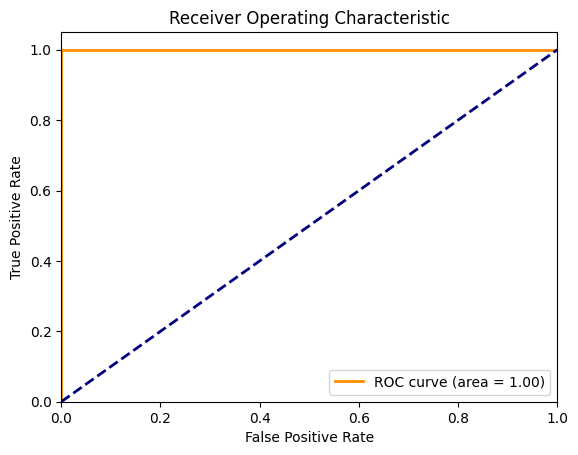

In [ ]:
# Visualize the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Adjust autoencoder architecture and hyperparameters as needed
from tensorflow.keras.layers import Dropout

In [ ]:
# Define an improved autoencoder architecture with dropout
input_img = Input(shape=(128, 128, 3))

In [ ]:
# Encoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Dropout(0.2)(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

In [ ]:
# Decoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Dropout(0.2)(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

In [ ]:
# Improved autoencoder model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse')

# autoencoder = Model(input_img, decoded)
# autoencoder.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), loss='mse')

# autoencoder = Model(input_img, decoded)
# autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')

In [ ]:
# Train the improved autoencoder
history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=64, validation_data=(X_val, X_val))

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - loss: 0.0499 - val_loss: 0.0127
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 0.0104 - val_loss: 0.0079
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 0.0077 - val_loss: 0.0066
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 0.0066 - val_loss: 0.0060
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 0.0059 - val_loss: 0.0056
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 0.0052 - val_loss: 0.0050
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 0.0047 - val_loss: 0.0044
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 12/100
250/25

In [ ]:
# Function to plot original, reconstructed images and their reconstruction errors
def plot_reconstruction(original, reconstructed, n=10):
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original images
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(original[i])
        plt.title("Original")
        plt.axis("off")

        # Reconstructed images
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(reconstructed[i])
        plt.title("Reconstructed")
        plt.axis("off")

        # Reconstruction error
        error = np.abs(original[i] - reconstructed[i])
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(error)
        plt.title("Error")
        plt.axis("off")
    plt.show()

In [ ]:
# Get some images from the validation set
num_images = 10
sample_images = X_val[:num_images]

In [ ]:
# Get the reconstructed images
reconstructed_images = autoencoder.predict(sample_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step


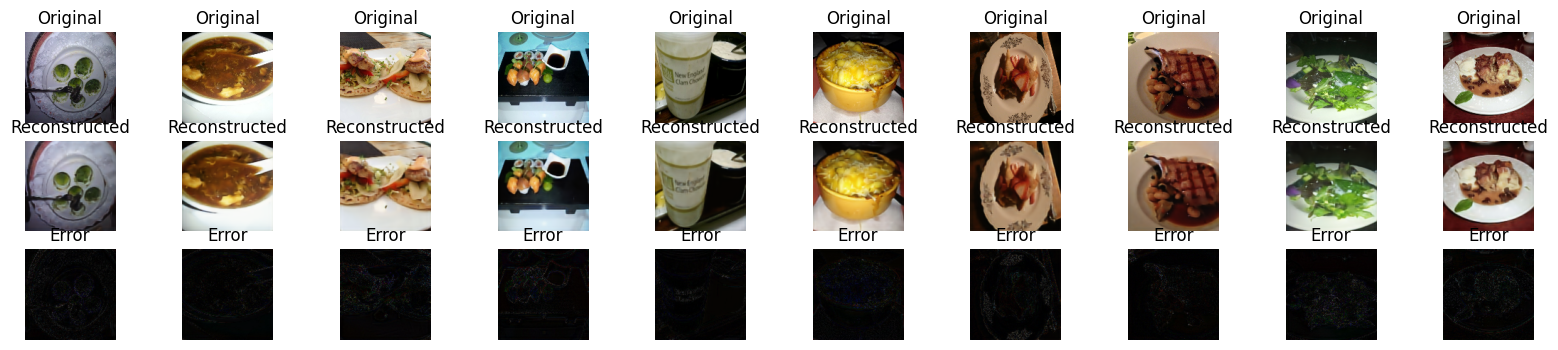

In [ ]:
# Plot the original, reconstructed images and their reconstruction errors
plot_reconstruction(sample_images, reconstructed_images)

In [ ]:
# Plot the reconstruction errors distribution
reconstruction_errors = np.mean(np.square(X_val - autoencoder.predict(X_val)), axis=(1, 2, 3))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


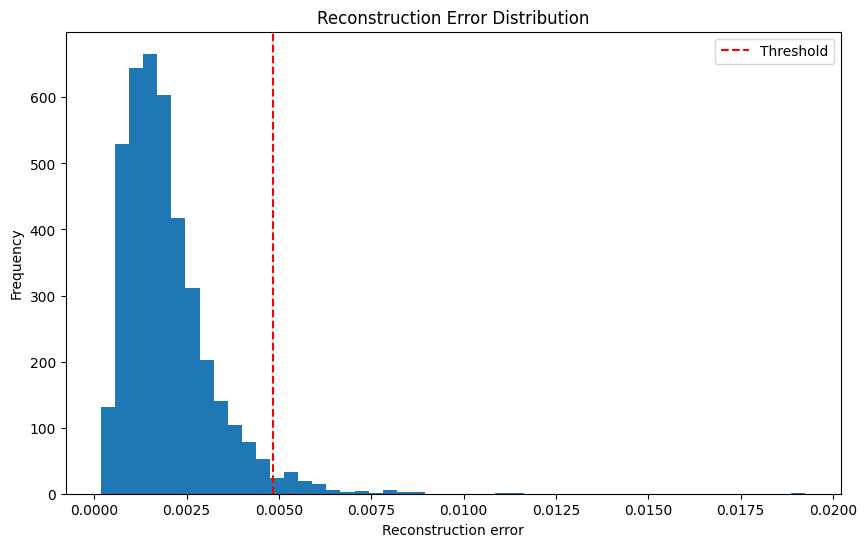

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors, bins=50)
plt.xlabel("Reconstruction error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution")
plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.show()